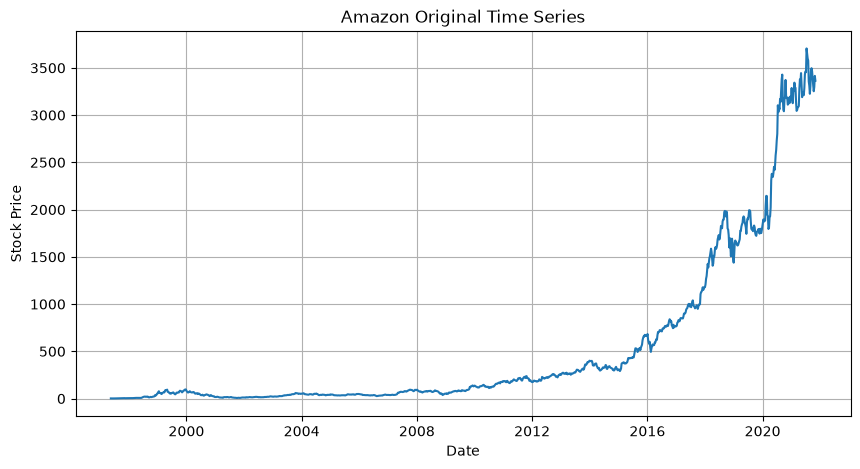

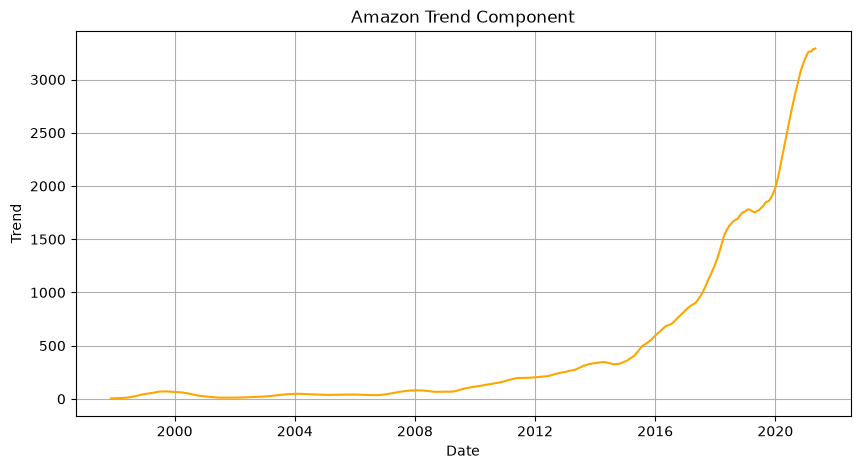

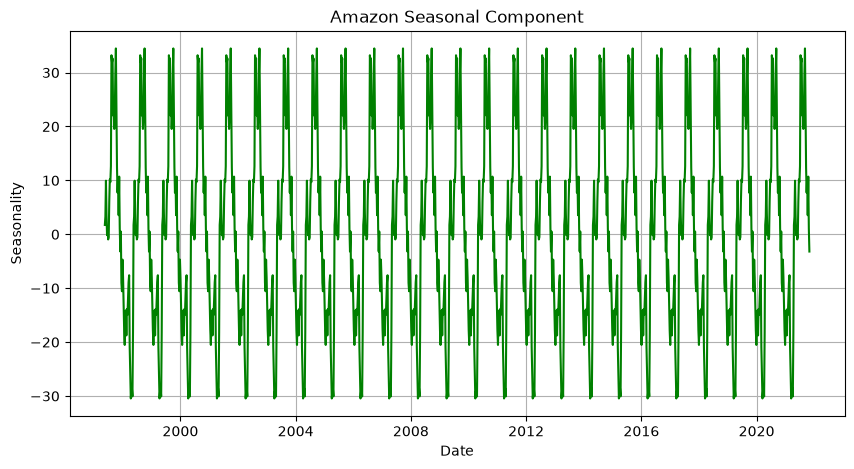

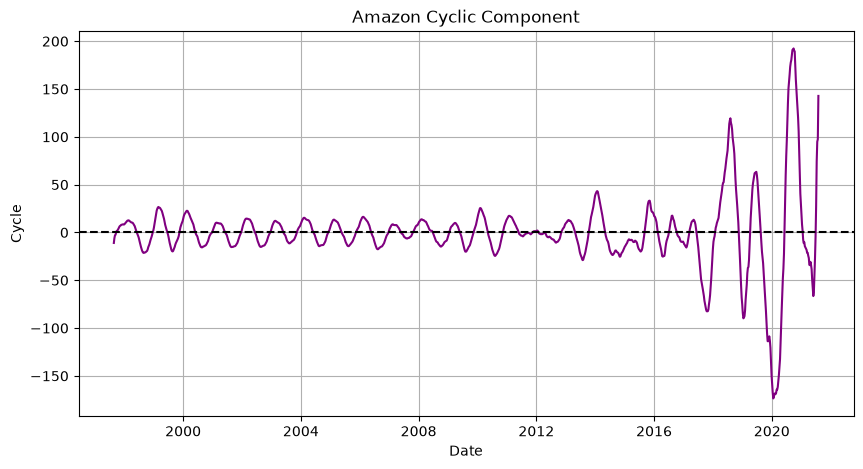

Amazon Analysis Completed


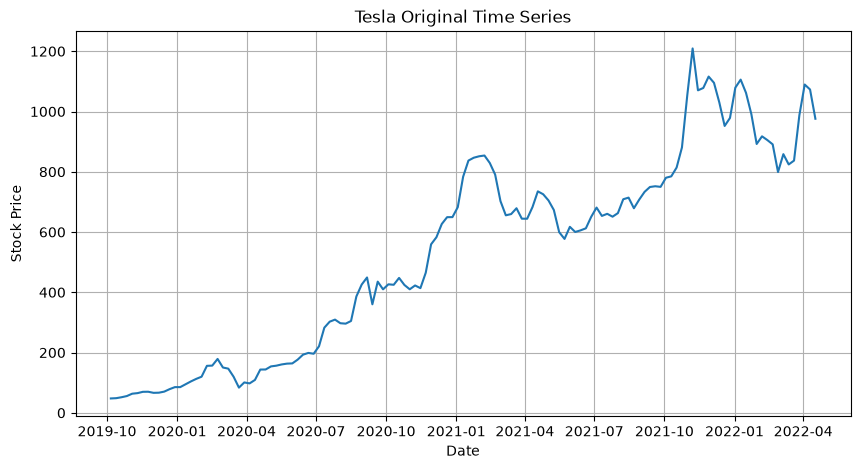

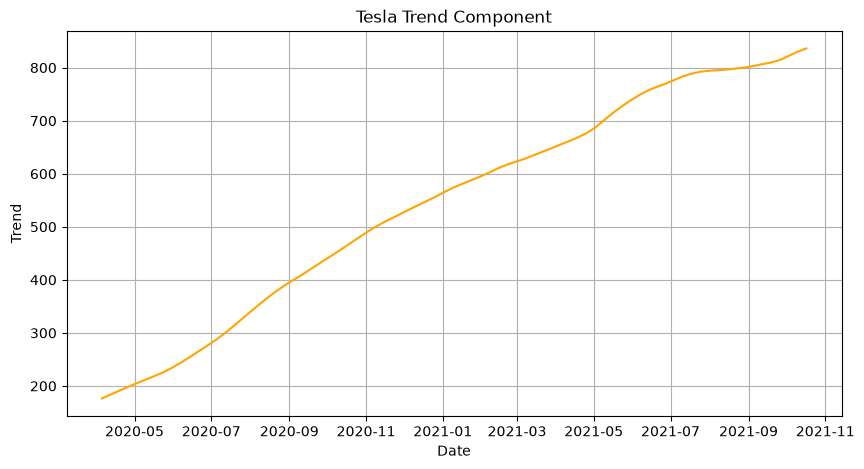

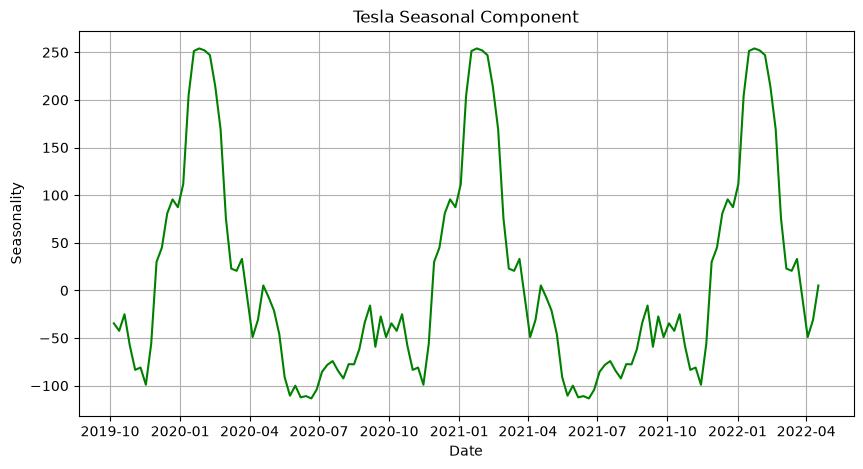

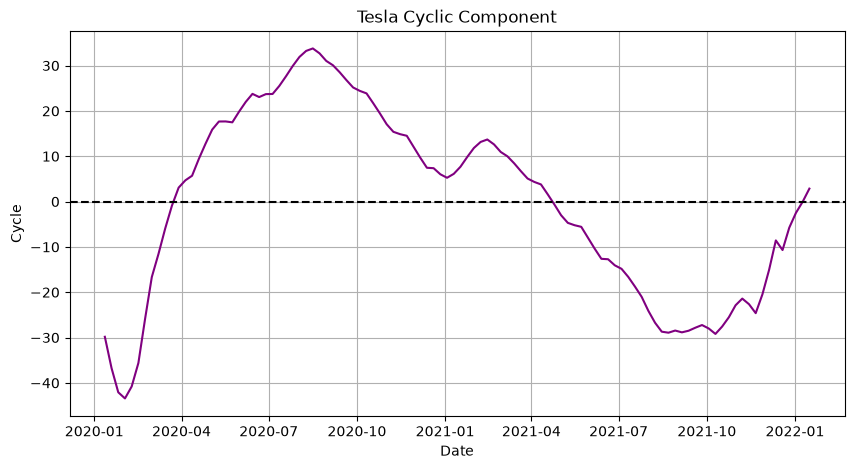

Tesla Analysis Completed


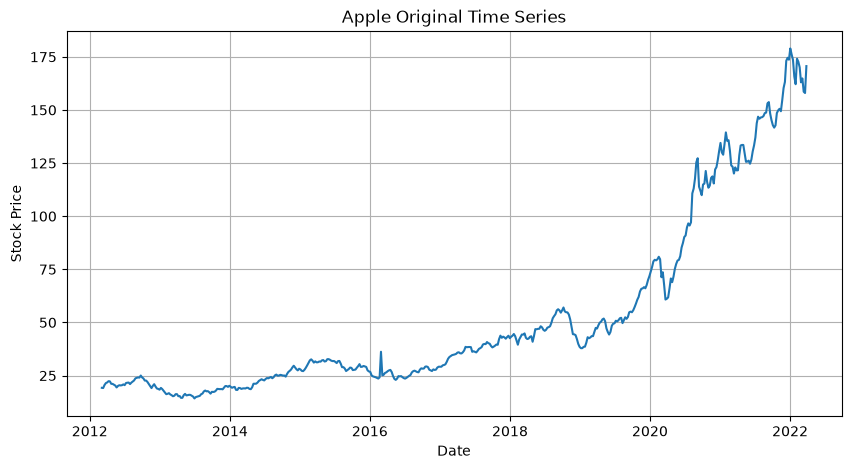

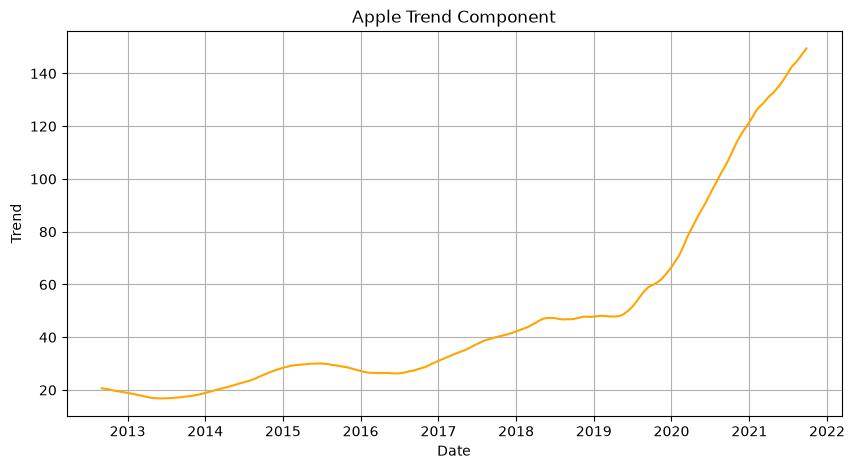

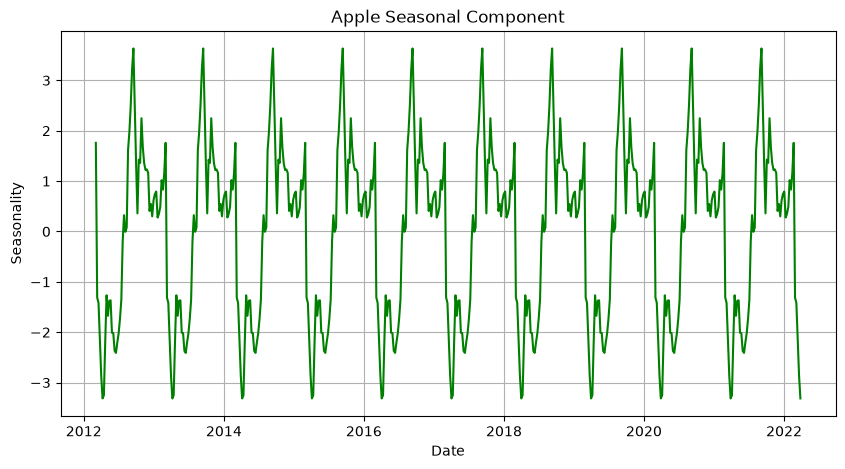

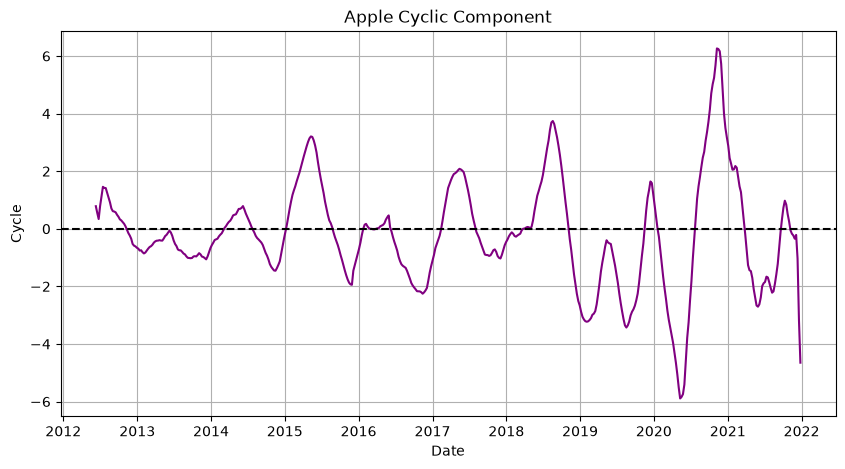

Apple Analysis Completed


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

def analyze_stock(file_path, stock_name):

    df = pd.read_csv(file_path)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

    if "Close" in df.columns:
        price_col = "Close"
    elif "Price" in df.columns:
        price_col = "Price"
    else:
        raise ValueError(f"Price column not found in {stock_name}")

    series = df.set_index("Date")[price_col]

    weekly = series.resample("W").mean().dropna()

    result = seasonal_decompose(
        weekly,
        model="additive",
        period=52
    )

    plt.figure(figsize=(10, 5))
    plt.plot(weekly)
    plt.title(f"{stock_name} Original Time Series")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(result.trend, color="orange")
    plt.title(f"{stock_name} Trend Component")
    plt.xlabel("Date")
    plt.ylabel("Trend")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(result.seasonal, color="green")
    plt.title(f"{stock_name} Seasonal Component")
    plt.xlabel("Date")
    plt.ylabel("Seasonality")
    plt.grid(True)
    plt.show()

    cyclic = result.resid.rolling(
        window=26,
        center=True,
        min_periods=1
    ).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(cyclic, color="purple")
    plt.axhline(0, linestyle="--", color="black")
    plt.title(f"{stock_name} Cyclic Component")
    plt.xlabel("Date")
    plt.ylabel("Cycle")
    plt.grid(True)
    plt.show()

    print(f"{stock_name} Analysis Completed")

analyze_stock(
    r"C:\Users\1402s\Downloads\Amazon.csv",
    "Amazon"
)

analyze_stock(
    r"C:\Users\1402s\Downloads\TSLA.csv",
    "Tesla"
)

analyze_stock(
    r"C:\Users\1402s\Downloads\AAPL Historical Data.csv",
    "Apple"
)